In [13]:
from matplotlib.colors import BoundaryNorm, ListedColormap
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pandas as pd
import numpy as np
import pickle
import ast

In [14]:
# load amino acids from the aa_df in input data
aa = pd.read_csv('../../qcnn/input_data/amino_acid_map.csv')['AA']
aa = aa.drop(19).reset_index(drop=True)

In [15]:
# get the one-hot encoded representation of each peptide (1 x 189) for a 9-mer
def peptide_encode(peptide):
    data = {}
    for i, residue in enumerate(peptide):
        for amino in aa:
            key = f"P{i+1}_{amino}"
            data[key] = 1 if residue == amino else 0
    return pd.DataFrame([data])

In [16]:
# convert labels to 0-1 values
def map_0_1(preds):
    return (np.array(preds) > 0).astype(int)

main_dir = '../../'
file_mapping = {
    'ravi_qcnn_1348': main_dir + 'qcnn/experiments/exp11_immuno_ravi_bms_riaz/1348_binding_ravi.pkl',
    'ravi_qcnn_2456': main_dir + 'qcnn/experiments/exp11_immuno_ravi_bms_riaz/2456_immuno_binders_ravi.pkl',
    
    'ravi_ccnn_ltd_1348': main_dir + 'ccnn/output/limited_params/survival_results/1348_binding_ravi/results.csv',
    'ravi_ccnn_ltd_2456': main_dir + 'ccnn/output/limited_params/survival_results/2456_immuno_binders_ravi/results.csv',
    
    'ravi_ccnn_large_1348': main_dir + 'ccnn/output/large_params/survival_results/1348_binding_ravi/results.csv',
    'ravi_ccnn_large_2456': main_dir + 'ccnn/output/large_params/survival_results/2456_immuno_binders_ravi/results.csv',
    
    'rf_1348': main_dir + 'random_forest/experiments/binding_ravi_1348/pred_labels.pkl',
    'rf_2456': main_dir + 'random_forest/experiments/immuno_ravi_2456/pred_labels.pkl',
    
    'ravi_data':main_dir +  'qcnn/input_data/Ravi_Riaz_data/Ravi_2023_NatGen_patient.txt',
    'ravi_encoded': main_dir + 'qcnn/input_data/Ravi_Riaz_data/encoded_data/ravi_encoded_a0201.csv',    
    'ravi_ba': main_dir + 'qcnn/input_data/Ravi_Riaz_data/Ravi_2023_NatGen_samples_a0201_barank.csv',
}


# load in peptide data
peptide_pred_df = pd.read_csv(file_mapping['ravi_encoded'])[['Peptide']]

# get predicted qcnn labels 
with open(file_mapping['ravi_qcnn_2456'], 'rb') as f:
    qcnn_2456 = np.array(map_0_1(pickle.load(f)['test_pred']))
with open(file_mapping['ravi_qcnn_1348'], 'rb') as f:
    qcnn_1348 = np.array(map_0_1(pickle.load(f)['test_pred']))
qcnn_labels = qcnn_2456 & qcnn_1348
peptide_pred_df['qcnn_pred'] = qcnn_labels


# load in classical CNN predictions
models = ['ltd', 'large']
for model in models:
    data = pd.read_csv(file_mapping[f'ravi_ccnn_{model}_1348'])
    ccnn_1348 = np.array(ast.literal_eval(data['pred_labels'][0]))
    data = pd.read_csv(file_mapping[f'ravi_ccnn_{model}_2456'])
    ccnn_2456 = np.array(ast.literal_eval(data['pred_labels'][0]))
    ccnn_labels = ccnn_2456 & ccnn_1348
    peptide_pred_df[f'ccnn_{model}_pred'] = ccnn_labels
    

# load in random forest preds
with open(file_mapping['rf_1348'], 'rb') as f:
    rf_1348 = pickle.load(f)['avg_pred_labels']
with open(file_mapping['rf_2456'], 'rb') as f:
    rf_2456 = pickle.load(f)['avg_pred_labels']
rf_labels = rf_2456 & rf_1348
peptide_pred_df['rf_pred'] = rf_labels


peptide_pred_df.head()

,Peptide,qcnn_pred,ccnn_ltd_pred,ccnn_large_pred,rf_pred
0,SEAARARLD,0,0,0,0
1,EAARARLDL,0,0,0,0
2,AARARLDLL,1,0,0,0
3,ARARLDLLQ,0,0,0,0
4,RARLDLLQL,0,0,0,0


In [17]:
# encode each peptide into its one-hot representation
encoded_peptides = []
for i in tqdm(peptide_pred_df['Peptide']):
    pe = peptide_encode(i)
    encoded_peptides.append(pe)

bigmat = pd.concat(encoded_peptides, ignore_index=True)

bigmat.head()

100%|██████████| 209889/209889 [05:38<00:00, 620.54it/s]


,P1_A,P1_C,P1_D,P1_E,P1_F,P1_G,P1_H,P1_I,P1_K,P1_L,...,P9_M,P9_N,P9_P,P9_Q,P9_R,P9_S,P9_T,P9_V,P9_W,P9_Y
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
# add prediction labels for each peptide
bigmat['qcnn_pred'] = peptide_pred_df['qcnn_pred']
bigmat['ccnn_limited_pred'] = peptide_pred_df['ccnn_ltd_pred']
bigmat['ccnn_large_pred'] = peptide_pred_df['ccnn_large_pred']
bigmat['rf_pred'] = peptide_pred_df['rf_pred']

log_scale = True

all_results={}
for i in ['qcnn_pred', 'ccnn_limited_pred', 'ccnn_large_pred', 'rf_pred']:
    pos_pred = bigmat[bigmat[i] == 1]
    neg_pred = bigmat[bigmat[i] == 0]

    # sum aa values (first 180 is the 20x9 AA)
    pos_sum = pos_pred.iloc[:, :180].sum(axis=0).to_frame(name='value')
    pos_sum = pos_sum.reset_index()
    pos_sum.columns = ['position', 'value']

    neg_sum = neg_pred.iloc[:, :180].sum(axis=0).to_frame(name='value')
    neg_sum = neg_sum.reset_index()
    neg_sum.columns = ['position', 'value']

    # normalize values
    norm_pos = pos_sum['value'] / len(pos_pred)
    norm_neg = neg_sum['value'] / len(neg_pred)
    
    # avoid dividing by 0
    epsilon = 1e-6
    ratio = (norm_pos + epsilon) / (norm_neg + epsilon)
    
    bigmat_sum = pd.DataFrame({
        'position': pos_sum['position'],
        'value': ratio.astype(float)
    })
    bigmat_sum['value'] = bigmat_sum['value'].fillna(1)
    bigmat_sum['amino_acid'] = [i.split('_')[1] for i in bigmat_sum['position']]
    bigmat_sum['pos'] = [i.split('_')[0].replace('P', '') for i in bigmat_sum['position']]
    bigmat_sum = bigmat_sum.drop(columns = 'position')

    # subset to only positions 2,4,5,6 --> 3,5,6,7    1,3,4,8 --> 2,4,5,8
    bigmat_sum = bigmat_sum[bigmat_sum['pos'].isin(['2', '3', '4', '5', '6', '7', '9'])]

    if log_scale:
        epsilon = 1e-6  # small constant to avoid log(0)
        bigmat_sum['value'] = np.log2(bigmat_sum['value'] + epsilon)
        bigmat_sum['value'] = bigmat_sum['value'].clip(lower=-3, upper=3)
    all_results[i] = bigmat_sum


bigmat_sum.head()

,value,amino_acid,pos
20,-0.347363,A,2
21,-1.249783,C,2
22,-1.195340,D,2
23,-1.918107,E,2
24,-1.163218,F,2


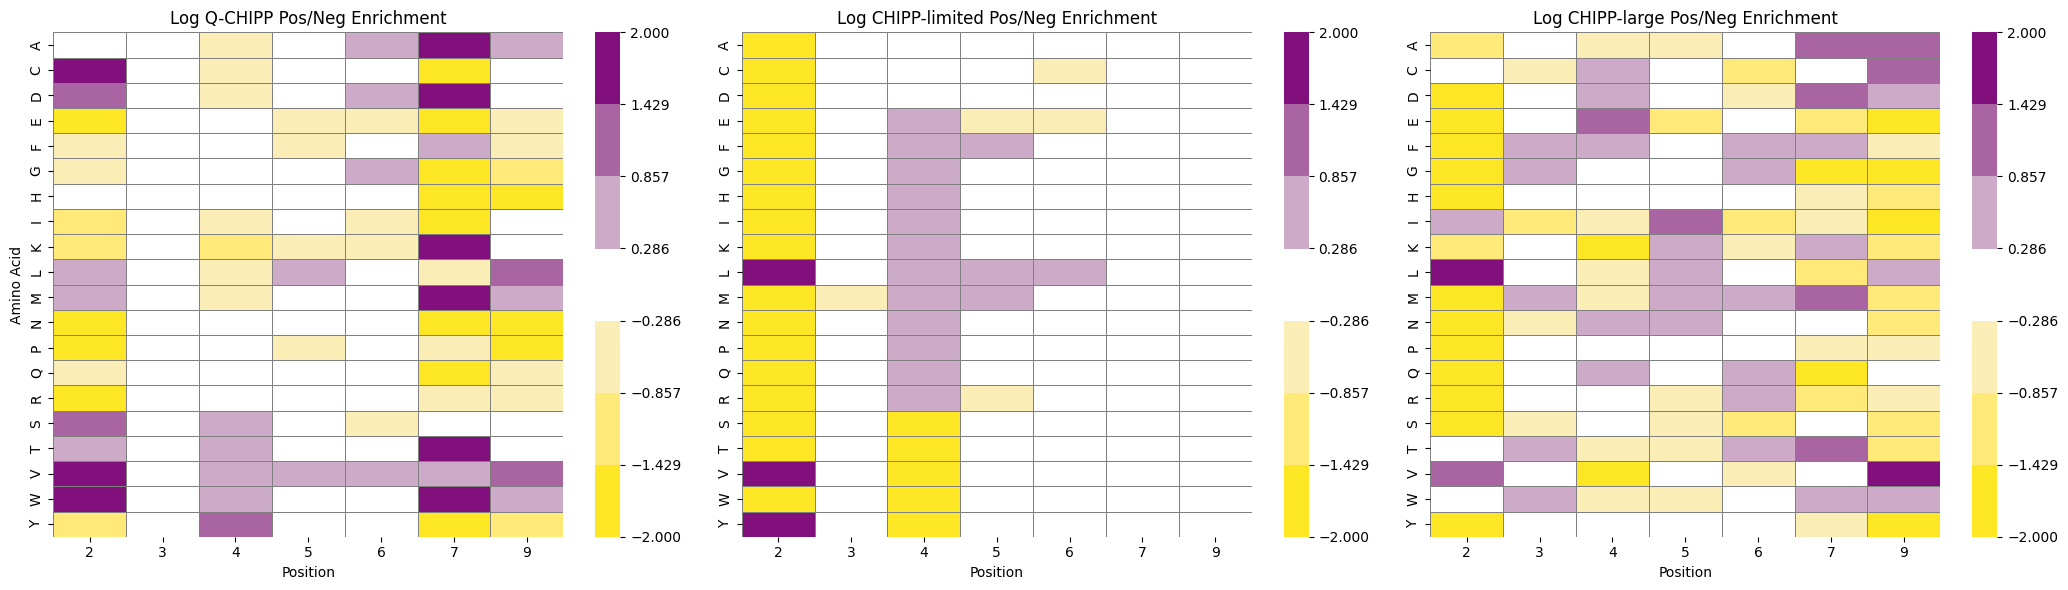

In [19]:
heatmap_dfs = []
for i in ['qcnn_pred', 'ccnn_limited_pred', 'ccnn_large_pred',]:
    heatmap_dfs.append(all_results[i].pivot(index='amino_acid', columns='pos', values='value'))

custom_colors = ["#fde725", "#ffea79", "#fbedb6", "white", "#ceaac9", "#a964a2", "#810f7c"]
cmap = ListedColormap(custom_colors)
boundaries = np.linspace(0, 2, 1)

if log_scale:
    boundaries = np.linspace(-2, 2, 8)
norm = BoundaryNorm(boundaries, ncolors=len(custom_colors))

fig, axes = plt.subplots(1, 3, figsize=(len(heatmap_dfs) * 7, 6), sharey=False)

for i, model in enumerate(['Q-CHIPP', 'CHIPP-limited', 'CHIPP-large']):
    sns.heatmap(
        heatmap_dfs[i],
        cmap=cmap,
        norm=norm,
        cbar=True,
        ax=axes[i],
        linewidths=0.5,
        linecolor='gray',
    )
    axes[i].set_title(f"Log {model} Pos/Neg Enrichment")
    axes[i].set_xlabel("Position")
    axes[i].set_ylabel("Amino Acid" if i == 0 else "")

plt.tight_layout()
plt.savefig('survival_plots_fgh.svg', dpi=300)
plt.show()